In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db_connection import get_engine

In [2]:
# Load Data
query = """
    SELECT *
    FROM application
"""
engine = get_engine('home_credit')
df = pd.read_sql(query, engine)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Calculate skewness for AMT_INCOME_TOTAL, AMT_CREDIT, and AMT_ANNUITY
# Print all three values, interpret whether each is normally distributed or skewed

from src.utils import skewness_test

features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

print("=" * 60)
print("SKEWNESS")
for feature in features:
    skewness = skewness_test(df, feature)
    skewness_check = "Skewed" if skewness > 1 else "Normal"
    print(" " * 40)
    print(f'{feature}_SKEWNESS                   {skewness} ({skewness_check})')

print(" " * 60)
print('=' * 60)
print("INTERPRETATION")
print(f"""If the skewness is above 1 that means the data is not normally distributed and we go for IQR method 
for outlier detection. In our case all of these features are skewed with income being extremely skewed.""")

SKEWNESS
                                        
AMT_INCOME_TOTAL_SKEWNESS                   391.56 (Skewed)
                                        
AMT_CREDIT_SKEWNESS                   1.23 (Skewed)
                                        
AMT_ANNUITY_SKEWNESS                   1.58 (Skewed)
                                                            
INTERPRETATION
If the skewness is above 1 that means the data is not normally distributed and we go for IQR method 
for outlier detection. In our case all of these features are skewed with income being extremely skewed.


In [4]:
# Calculate Q1, Q3, IQR, lower bound, and upper bound for AMT_INCOME_TOTAL, AMT_CREDIT and AMT_ANNUITY
# Count how many rows fall outside the bounds (outliers)

from src.utils import outlier_detection

features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

for feature in features:
    outlier = outlier_detection(df, feature)
    print(" " * 33)
    print("=" * 33)
    print(" " * 33)
    print(f"{outlier}")

                                 
                                 
AMT_INCOME_TOTAL_OUTLIER
Normal     0.95
Outlier    0.05
Name: proportion, dtype: float64
                                 
                                 
AMT_CREDIT_OUTLIER
Normal     0.98
Outlier    0.02
Name: proportion, dtype: float64
                                 
                                 
AMT_ANNUITY_OUTLIER
Normal     0.98
Outlier    0.02
Name: proportion, dtype: float64


                                                                              
Box Plot of AMT_INCOME_TOTAL
                                                                              


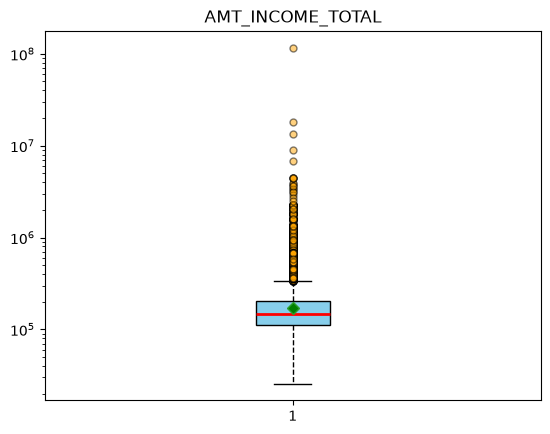

                                                                              
Box Plot of AMT_CREDIT
                                                                              


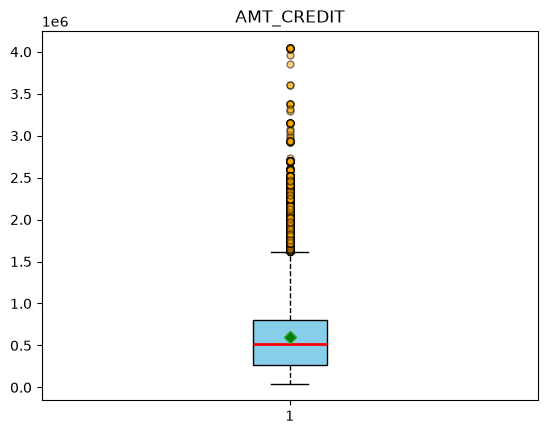

                                                                              
Box Plot of AMT_ANNUITY
                                                                              


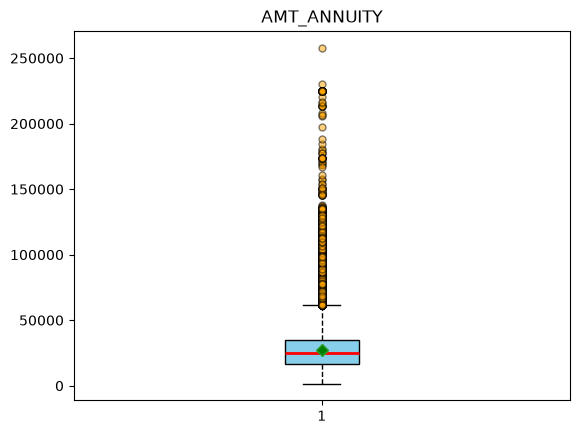

In [15]:
# Plot boxplots for AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY

features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

for feature in features:
    if feature == 'AMT_INCOME_TOTAL':
        plt.yscale('log')
    
    print(" " * 78)
    print("=" * 78)
    print(f'Box Plot of {feature}')
    print(" " * 78)
    plt.boxplot(df[feature].dropna(),
                patch_artist=True,
                boxprops=dict(facecolor='skyblue', color='black'),
                whiskerprops=dict(color='black', linestyle='--'),
                capprops=dict(color='black'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='orange', markersize=5, alpha=0.5),
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='green')
                )
    plt.title(feature)
    plt.show()